***Comparing Market Regimes Across the S&P 500 and Major Tech Stocks***


## 1. Introduction

Financial markets are often assumed to behave in a relatively stable and predictable way over time. However, in practice, market conditions can change significantly, with periods of stability followed by sudden increases in volatility and uncertainty. Understanding these changes is important for risk management, investment decisions, and financial modelling.

The aim of this project is to analyse historical financial data from the S&P 500 index alongside selected large-cap technology stocks, including Apple, Microsoft, and Tesla. By examining price movements, returns, and volatility, the project seeks to explore whether market behaviour appears consistent over time or whether there are observable patterns that suggest shifts in underlying conditions.

This analysis focuses on identifying differences in volatility and correlation across assets, as well as investigating whether volatility tends to cluster over time. These observations provide a foundation for more advanced modelling approaches, such as regime-switching models, which aim to formally capture changes in market behaviour.

## 2. Data Description

The dataset used in this project consists of historical daily price data obtained from Yahoo Finance. The assets analysed include the S&P 500 index (^GSPC) and three major technology companies: Apple (AAPL), Microsoft (MSFT), and Tesla (TSLA).

The data spans from 2015 to 2024 and includes key variables such as opening price, high, low, closing price, and trading volume. For the purposes of this analysis, the closing price is used as the primary variable, as it represents the final market value for each trading day.

Daily returns are calculated as the percentage change in closing prices, providing a standardised measure of asset performance. These returns are then used to compute volatility and analyse patterns in market behaviour over time.

Using a combination of an index and individual equities allows for a comparison between overall market trends and the behaviour of specific high-growth stocks.

In [4]:
# import core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

# Make plots look nicer
plt.style.use('seaborn-v0_8')

print("Libraries imported successfully")

Libraries imported successfully


#Downloading data

In [5]:
# Define tickers
tickers = ["^GSPC", "AAPL", "MSFT", "TSLA"]

# Download historical data
data = yf.download(tickers, start="2015-01-01", end="2024-12-31")

# Shows the first few rows
data.head()

/tmp/ipykernel_3668/2466068512.py:5: FutureWarning: YF.download() has changed argument auto_adjust default to True
  data = yf.download(tickers, start="2015-01-01", end="2024-12-31")
[*********************100%***********************]  4 of 4 completed


Price           Close                                          High  \
Ticker           AAPL       MSFT       TSLA        ^GSPC       AAPL   
Date                                                                  
2015-01-02  24.214895  39.767689  14.620667  2058.199951  24.682228   
2015-01-05  23.532721  39.401997  14.006000  2020.579956  24.064284   
2015-01-06  23.534935  38.823669  14.085333  2002.609985  23.794071   
2015-01-07  23.864948  39.316944  14.063333  2025.900024  23.964616   
2015-01-08  24.781895  40.473572  14.041333  2062.139893  24.839481   

Price                                                Low             \
Ticker           MSFT       TSLA        ^GSPC       AAPL       MSFT   
Date                                                                  
2015-01-02  40.328995  14.883333  2072.360107  23.776355  39.580589   
2015-01-05  39.742180  14.433333  2054.439941  23.346674  39.333958   
2015-01-06  39.759178  14.280000  2030.250000  23.173914  38.730118   
2015-01-07  39.512550  14.318667  2029.609985  23.632389  38.687603   
2015-01-08  40.609646  14.253333  2064.080078  24.075359  39.733669   

Price                                    Open                        \
Ticker           TSLA        ^GSPC       AAPL       MSFT       TSLA   
Date                                                                  
2015-01-02  14.217333  2046.040039  24.671153  39.682644  14.858000   
2015-01-05  13.810667  2017.339966  23.984549  39.436013  14.303333   
2015-01-06  13.614000  1992.439941  23.596950  39.444508  14.004000   
2015-01-07  13.985333  2005.550049  23.743131  39.104328  14.223333   
2015-01-08  14.000667  2030.609985  24.192747  39.759182  14.187333   

Price                       Volume                                  
Ticker            ^GSPC       AAPL      MSFT      TSLA       ^GSPC  
Date                                                                
2015-01-02  2058.899902  212818400  27913900  71466000  2708700000  
2015-01-05  2054.439941  257142000  39673900  80527500  3799120000  
2015-01-06  2022.150024  263188400  36447900  93928500  4460110000  
2015-01-07  2005.550049  160423600  29114100  44526000  3805480000  
2015-01-08  2030.609985  237458000  29645200  51637500  3934010000

In [6]:
# Keep only closing prices
close_prices = data["Close"].copy()

# Show first few rows
close_prices

Ticker,AAPL,MSFT,TSLA,^GSPC
Date,,,,
2015-01-02,24.214895,39.767689,14.620667,2058.199951
2015-01-05,23.532721,39.401997,14.006000,2020.579956
2015-01-06,23.534935,38.823669,14.085333,2002.609985
2015-01-07,23.864948,39.316944,14.063333,2025.900024
2015-01-08,24.781895,40.473572,14.041333,2062.139893


#Checking the data

In [7]:
# Basic info
print(close_prices.info())

# Missing values
print("\n Missing values:")
print(close_prices.isnull().sum())

# Preview
close_prices.tail()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2515 entries, 2015-01-02 to 2024-12-30
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AAPL    2515 non-null   float64
 1   MSFT    2515 non-null   float64
 2   TSLA    2515 non-null   float64
 3   ^GSPC   2515 non-null   float64
dtypes: float64(4)
memory usage: 98.2 KB
None

 Missing values:
Ticker
AAPL     0
MSFT     0
TSLA     0
^GSPC    0
dtype: int64


Ticker,AAPL,MSFT,TSLA,^GSPC
Date,,,,
2024-12-23,253.883118,431.078857,430.600006,5974.069824
2024-12-24,256.797180,435.119690,462.279999,6040.040039
2024-12-26,257.612732,433.911407,454.130005,6037.589844
2024-12-27,254.201370,426.404083,431.660004,5970.839844
2024-12-30,250.829773,420.758667,417.410004,5906.939941


#Plotting closing prices


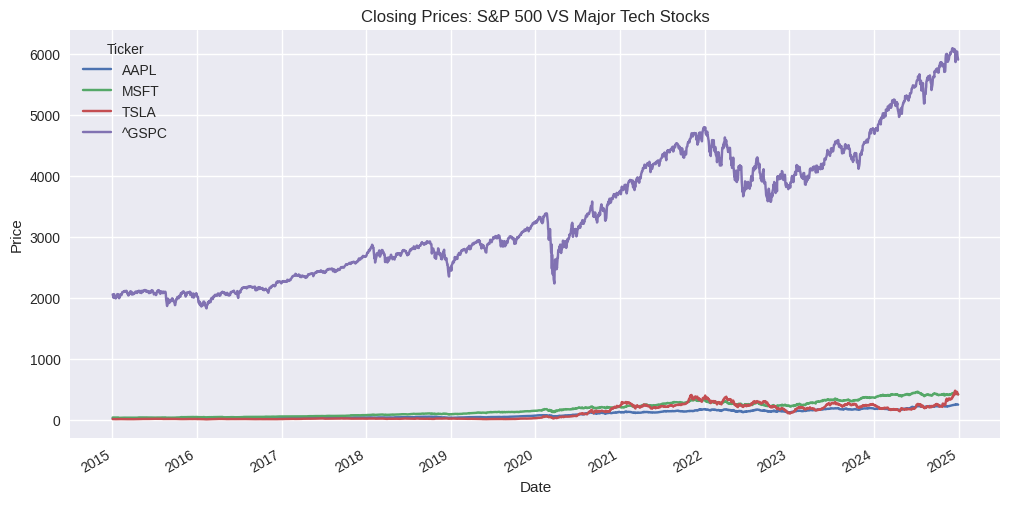

In [8]:
close_prices.plot(figsize=(12,6))
plt.title("Closing Prices: S&P 500 VS Major Tech Stocks")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid(True)
plt.show()

From the chart the SP500's (`^GSPC`) price character is much clearer but also seems much more volatile then others. The chart isn't ideal for direct comparison yet

#Normalisation of share prices

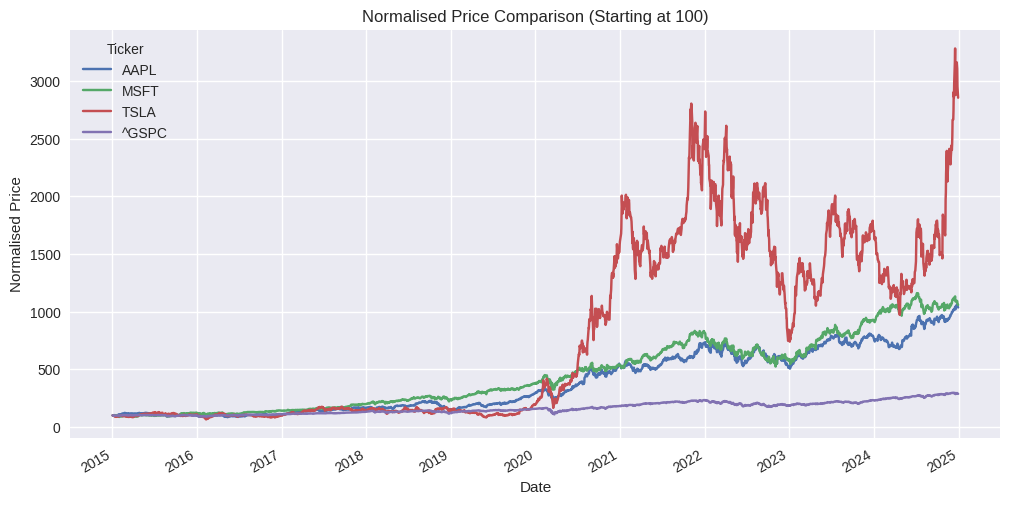

In [9]:
# Normalise prices so all assets start at 100
normalised_prices = close_prices / close_prices.iloc[0] * 100

# Plot normalised prices
normalised_prices.plot(figsize=(12,6))
plt.title("Normalised Price Comparison (Starting at 100)")
plt.xlabel("Date")
plt.ylabel("Normalised Price")
plt.grid(True)
plt.show()

## 3. Price Analysis

The initial analysis focuses on the closing price of each asset over time. The S&P 500 shows a relatively steady upward trend, reflecting long-term market growth. In contrast, individual stocks such as Tesla display more pronounced fluctuations, with periods of rapid growth followed by sharp declines.

To enable a fair comparison between assets with different price levels, prices are normalised so that all series start from the same baseline. This highlights differences in growth rates and variability more clearly.

From the normalised price chart, it is evident that while all assets generally trend upwards over the long term, the magnitude and consistency of this growth varies significantly. Tesla, in particular, exhibits more extreme movements compared to the broader market and other technology stocks.

#Calculating daily returns

In [10]:
# Daily percentage returns
returns = close_prices.pct_change().dropna()

# Show first few rows
returns.head()

Ticker,AAPL,MSFT,TSLA,^GSPC
Date,,,,
2015-01-05,-0.028172,-0.009196,-0.042041,-0.018278
2015-01-06,0.000094,-0.014678,0.005664,-0.008893
2015-01-07,0.014022,0.012706,-0.001562,0.011630
2015-01-08,0.038422,0.029418,-0.001564,0.017888
2015-01-09,0.001072,-0.008405,-0.018802,-0.008404


Plot daily returns

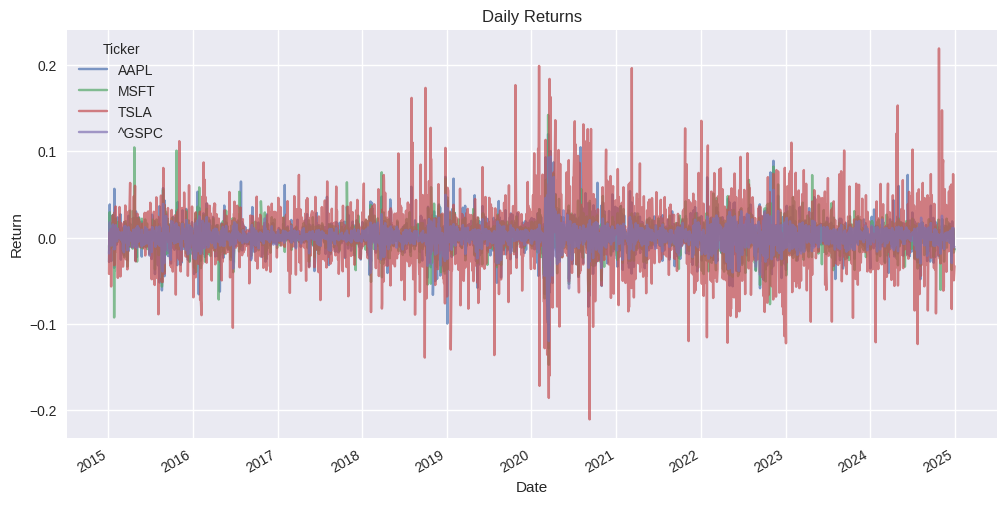

In [11]:
returns.plot(figsize=(12,6), alpha = 0.7)
plt.title("Daily Returns")
plt.xlabel("Date")
plt.ylabel("Return")
plt.grid(True)
plt.show()

## 4. Return Analysis

Daily returns are calculated as the percentage change in closing prices, providing a clearer view of short-term market behaviour. Unlike price levels, returns fluctuate around zero and capture the day-to-day variability in asset performance.

The return series shows that while all assets experience both positive and negative movements, the magnitude of these movements differs considerably. Tesla exhibits much larger swings in returns, indicating higher short-term risk, while the S&P 500 shows relatively smaller and more stable fluctuations.

This highlights an important distinction between individual growth stocks and diversified market indices, with the latter generally providing more stable return behaviour.

#Comparing volatility
- This can be done by using the standard deviation of returns

In [12]:
# Calculate overall volatility
volatility = returns.std().sort_values(ascending=False)

print("Volatility comparison:")
print(volatility)

Volatility comparison:
Ticker
TSLA     0.036009
AAPL     0.017932
MSFT     0.017098
^GSPC    0.011232
dtype: float64


Now lets plot it

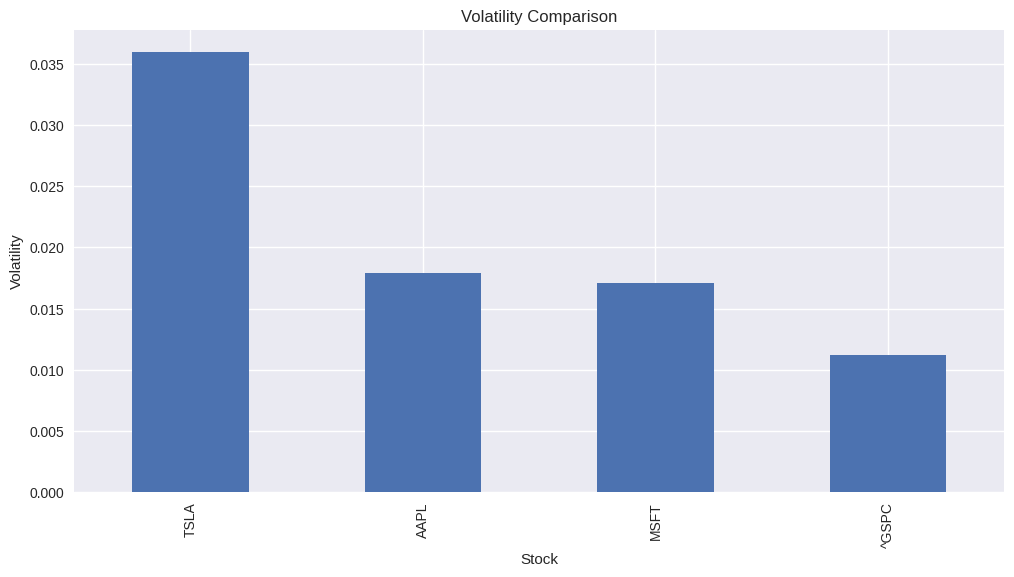

In [13]:
volatility.plot(kind='bar', figsize=(12,6))
plt.title("Volatility Comparison")
plt.xlabel("Stock")
plt.ylabel("Volatility")
plt.grid(True)
plt.show()

## 5. Volatility Analysis

Volatility is measured as the standard deviation of daily returns and represents the degree of variation in asset prices. Higher volatility indicates greater uncertainty and risk.

The results show that Tesla has the highest level of volatility among the assets analysed, followed by Apple and Microsoft, while the S&P 500 exhibits the lowest volatility. This is consistent with expectations, as broad market indices tend to smooth out individual asset fluctuations.

These differences in volatility highlight how risk varies across assets and reinforce the importance of diversification in financial markets.

#Calculating rolling volatility
* Shows volatility changes over time

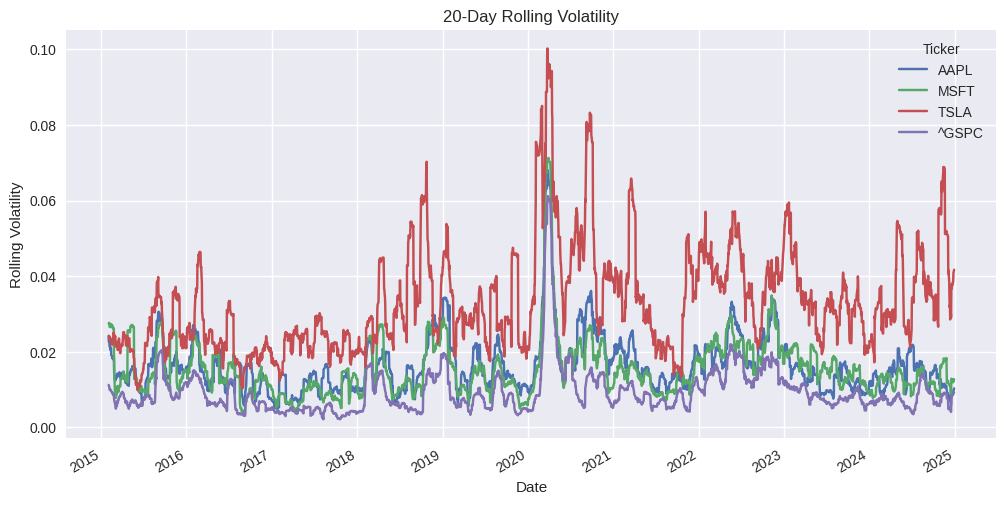

In [14]:
# 20-day rolling volatility
rolling_volatility = returns.rolling(window=20).std()

# Plot rolling volatility
rolling_volatility.plot(figsize=(12, 6))
plt.title("20-Day Rolling Volatility")
plt.xlabel("Date")
plt.ylabel("Rolling Volatility")
plt.grid(True)
plt.show()

## 6. Rolling Volatility

To examine how volatility changes over time, a rolling standard deviation of returns is calculated using a 20-day window. This allows for the observation of short-term fluctuations in market risk.

The results show that volatility is not constant, but instead varies significantly over time. Periods of high volatility tend to cluster together, often corresponding to times of market stress or uncertainty, while calmer periods are characterised by relatively low and stable volatility.

This behaviour suggests that financial markets may transition between different states, rather than following a single, stable pattern. These observations provide an important motivation for exploring regime-based models, which aim to capture such changes more formally.

An additional observation is that periods of elevated volatility often coincide across multiple assets, particularly during market-wide events. However, the magnitude of these spikes differs, with Tesla consistently exhibiting larger increases.

This suggests that while systemic risk affects all assets, individual characteristics still play a significant role in how strongly each asset reacts. This reinforces the idea that market regimes may be driven by both global and asset-specific factors.

#Calculating correlations

In [15]:
# Correlation matrix
correlation_matrix = returns.corr()

print(correlation_matrix)

Ticker      AAPL      MSFT      TSLA     ^GSPC
Ticker                                        
AAPL    1.000000  0.682823  0.418059  0.746938
MSFT    0.682823  1.000000  0.399694  0.798147
TSLA    0.418059  0.399694  1.000000  0.465055
^GSPC   0.746938  0.798147  0.465055  1.000000


# Plotting correlations

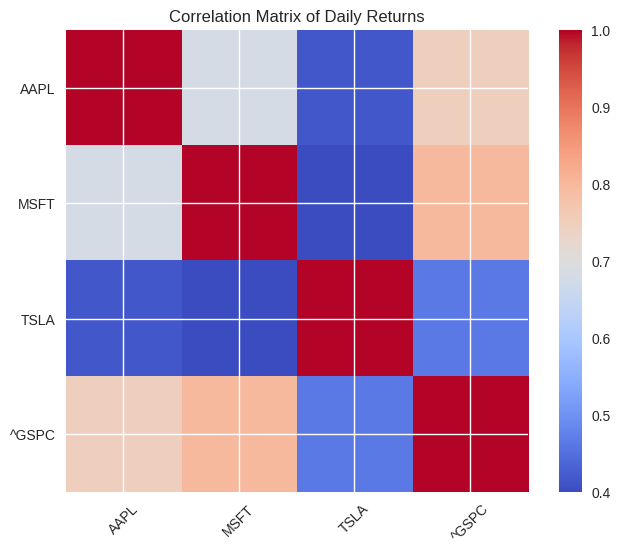

In [16]:
plt.figure(figsize=(8, 6))
plt.imshow(correlation_matrix, cmap="coolwarm", interpolation="nearest")
plt.colorbar()
plt.xticks(range(len(correlation_matrix.columns)), correlation_matrix.columns, rotation=45)
plt.yticks(range(len(correlation_matrix.columns)), correlation_matrix.columns)
plt.title("Correlation Matrix of Daily Returns")
plt.show()

## 7. Correlation Analysis

Correlation analysis is used to examine the relationship between asset returns. The results show that all assets are positively correlated, meaning they generally move in the same direction.

The strongest correlation is observed between Apple and Microsoft, reflecting their similar roles within the technology sector. Tesla, while still positively correlated with the market, exhibits weaker relationships due to its higher volatility and more independent price movements.

Although correlations are generally strong, differences in volatility indicate that assets can still behave quite differently in terms of risk, even when they follow similar overall trends.

#Basic summary statistics

In [17]:
summary_stats = returns.describe().T
summary_stats["volatility"] = returns.std()
summary_stats["mean_return"] = returns.mean()

summary_stats

,count,mean,std,min,25%,50%,75%,max,volatility,mean_return
Ticker,,,,,,,,,,
AAPL,2514.0,0.001091,0.017932,-0.128647,-0.007328,0.001001,0.010144,0.119808,0.017932,0.001091
MSFT,2514.0,0.001085,0.017098,-0.147390,-0.006728,0.000958,0.009779,0.142169,0.017098,0.001085
TSLA,2514.0,0.001979,0.036009,-0.210628,-0.016160,0.001264,0.019256,0.219190,0.036009,0.001979
^GSPC,2514.0,0.000483,0.011232,-0.119841,-0.003773,0.000639,0.005756,0.093828,0.011232,0.000483


## 8. Key Findings

- Tesla exhibits significantly higher volatility compared to the other assets  
- The S&P 500 shows the most stable return behaviour  
- Volatility is not constant and changes over time  
- High-volatility periods tend to cluster together  
- Assets are positively correlated, but differ in their risk profiles  

These findings suggest that market behaviour is dynamic and may shift between different states over time.

## 9. Conclusion

This project explored the behaviour of the S&P 500 and selected technology stocks using price data, returns, and volatility analysis. The results show that while assets generally move together, there are clear differences in their levels of risk and variability.

A key finding is that volatility is not constant over time, but instead appears in clusters, with periods of high instability followed by calmer phases. This indicates that financial markets may operate under different underlying conditions rather than following a single stable pattern.

Additionally, while assets are positively correlated, differences in volatility suggest that they respond differently to market conditions, highlighting the importance of both systemic and asset-specific factors.

These observations support the idea that market behaviour can be better understood as a series of changing regimes. This provides a strong foundation for future work using models such as Hidden Markov Models, which aim to formally identify and model these latent market states.

## 10. Limitations

This analysis is based on historical price data and focuses primarily on returns and volatility. It does not incorporate external factors such as macroeconomic indicators, interest rates, or market sentiment, which may also influence market behaviour.

In addition, the analysis is descriptive rather than predictive, meaning it identifies patterns but does not attempt to forecast future movements.

Future work could extend this analysis by incorporating additional data sources and applying more advanced modelling techniques.